# 14.3 · Connected components and region cleanup

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain connected components and region cleanup using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[08 · Color Spaces](../../08-color-spaces/README.md), [11 · Morphological Image Processing](../../11-morphological-image-processing/README.md), [13 · Edge and Corner Detection](../../13-edge-and-corner-detection/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Segmentation assigns a label to each pixel. Classical methods use explicit assumptions about intensity, color or connectivity. They are useful baselines because their failure conditions are easier to inspect than those of a large trained model.

## 2. Intuition

Connected-component labeling groups adjacent foreground pixels after thresholding. Four-connectivity joins horizontal and vertical neighbors; eight-connectivity also joins diagonals. Component size filters remove specks but may remove real small objects. Compare the full pipeline against a known mask using IoU rather than visual impression alone.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 14
LESSON = 2
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
J=\sum_i\lVert x_i-\mu_{c_i}\rVert^2
$$

xi is a pixel feature vector, ci its cluster assignment and μ the selected cluster center. For values [1,2] assigned to center 1.5, the summed squared distance is 0.5. K-means decreases this objective but may reach a local solution.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
values = np.array([1.0, 2.0])
center = values.mean()
objective = ((values - center) ** 2).sum()
assert np.isclose(objective, 0.5)
print(center, objective)

1.5 0.5


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The Otsu reference sweeps histogram partitions, k-means updates assignments and means, and the component reference uses a queue to flood each unvisited foreground region.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def segmentation(lesson, seed, amount):
    image = picture(seed)
    if lesson == 0:
        g = n.gray(image).astype(np.uint8)
        threshold, mask = n.otsu(g)
        lib, _ = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return Result(
            "14 · Global and adaptive thresholding",
            {
                "Input": g,
                "Otsu mask": mask,
                "Adaptive threshold": cv2.adaptiveThreshold(
                    g, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 15, 5
                ),
            },
            metrics={"reference_threshold": threshold, "opencv_threshold": float(lib)},
        )
    if lesson == 1:
        labels, centers = n.kmeans(image.reshape(-1, 3) / 255, k=max(2, int(3 * amount)), seed=seed)
        return Result(
            "14 · K-means region assignment",
            {
                "RGB": image,
                "Cluster map": labels.reshape(image.shape[:2]),
                "Reconstructed colors": centers[labels].reshape(image.shape),
            },
            metrics={"clusters": len(centers)},
        )
    labels, count = n.components(shapes() > 0)
    return Result(
        "14 · Connected components",
        {"Binary input": shapes(), "4-connected labels": labels},
        metrics={"objects": count},
    )

{
  "objects": 3
}



## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/numerics.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.numerics import kmeans

display(Code(inspect.getsource(kmeans), language="python"))

def kmeans(values, k=3, iterations=20, seed=42):
    """Lloyd updates with deterministic initialization and empty-cluster repair."""
    values = np.asarray(values, float)
    if values.ndim != 2 or not 1 <= k <= len(values):
        raise ValueError("Expected N by D values and 1 <= k <= N.")
    rng = np.random.default_rng(seed)
    centers = values[rng.choice(len(values), k, replace=False)].copy()
    for _ in range(iterations):
        distances = ((values[:, None] - centers[None]) ** 2).sum(axis=2)
        labels = distances.argmin(axis=1)
        updated = np.array(
            [
                values[labels == i].mean(axis=0)
                if np.any(labels == i)
                else values[distances.min(axis=1).argmax()]
                for i in range(k)
            ]
        )
        if np.allclose(updated, centers):
            break
        centers = updated
    labels = ((values[:, None] - centers[None]) ** 2).sum(axis=2).argmin(axis=1)
    return labels, centers

## 8. Experiment

Add a lighting gradient before thresholding. Compare Otsu and adaptive masks at fixed object geometry, then inspect component counts.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "objects": 3
  },
  "second_seed": {
    "objects": 3
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

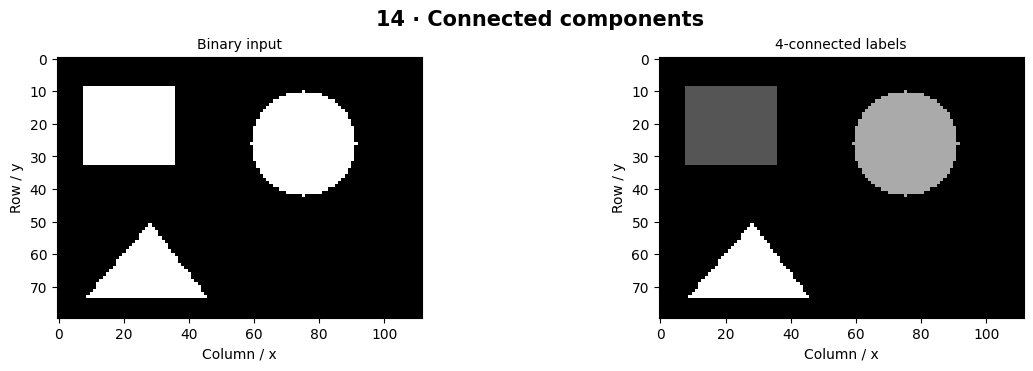

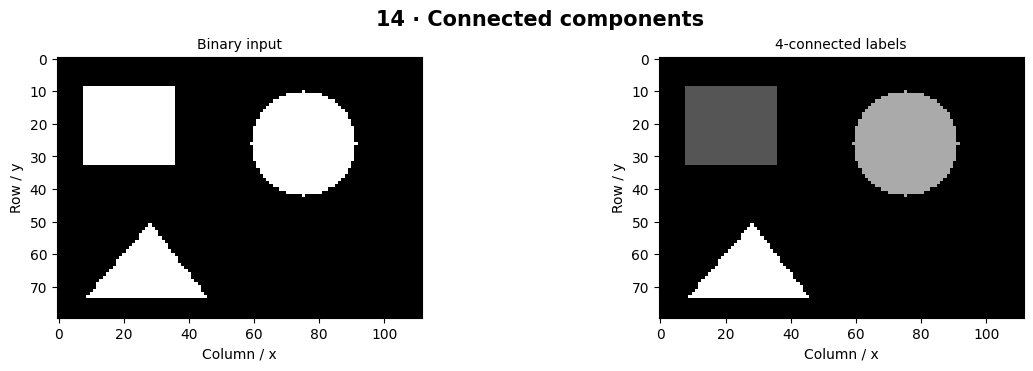

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Classical Segmentation Lab**. Separate regions with explicit assumptions and evaluation. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Cluster zero is not automatically background. Accuracy on a mostly-background image can be high for an empty prediction.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Add a lighting gradient before thresholding. Compare Otsu and adaptive masks at fixed object geometry, then inspect component counts.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Segment manufactured parts under uneven illumination and choose a thresholding or clustering method using a held-out set.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

Connected-component labeling groups adjacent foreground pixels after thresholding. Four-connectivity joins horizontal and vertical neighbors; eight-connectivity also joins diagonals. Component size filters remove specks but may remove real small objects. Compare the full pipeline against a known mask using IoU rather than visual impression alone.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

[15 · Video Processing](../../15-video-processing/README.md)

[Primary reference](https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)